## Getting the Dataset

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="lsXqkr4nP217WxcbT5nC")
project = rf.workspace("computer-vision-2v7mb").project("crowd-counting-dataset-w3o7w-l8c0s")
version = project.version(1)
dataset = version.download("yolov11")


## Processing the Dataset

In [3]:
import pandas as pd
import numpy as np

label = pd.read_csv('label.txt', delim_whitespace=True, header=None)

label

C:\Users\sarve\AppData\Local\Temp\ipykernel_13188\1179497867.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  label = pd.read_csv('label.txt', delim_whitespace=True, header=None)


FileNotFoundError: [Errno 2] No such file or directory: 'label.txt'

In [ ]:
points = (label[[1, 2]].values * 400).astype(int)
points

array([[203,  42],
       [283,  42],
       [200,  42],
       [214,  43],
       [331,  43],
       [324,  44],
       [334,  45],
       [306,  45],
       [240,  46],
       [314,  46],
       [264,  46],
       [213,  47],
       [294,  47],
       [248,  48],
       [259,  48],
       [203,  48],
       [274,  48],
       [209,  49],
       [325,  49],
       [269,  49],
       [307,  49],
       [365,  50],
       [193,  50],
       [199,  50],
       [223,  50],
       [232,  50],
       [290,  50],
       [303,  51],
       [215,  51],
       [284,  51],
       [380,  51],
       [263,  51],
       [240,  52],
       [328,  52],
       [218,  52],
       [244,  52],
       [354,  53],
       [358,  53],
       [227,  53],
       [267,  53],
       [296,  53],
       [320,  53],
       [250,  53],
       [343,  54],
       [334,  54],
       [349,  55],
       [361,  55],
       [339,  55],
       [279,  55],
       [328,  55],
       [210,  55],
       [393,  56],
       [397,

### Sample label

In [ ]:
matrix = np.zeros((400, 400), dtype=np.uint8)

# Set those positions to 1
matrix[points[:, 1], points[:, 0]] = 1
    
print(matrix.sum())
print(matrix.max())
matrix

292
1


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

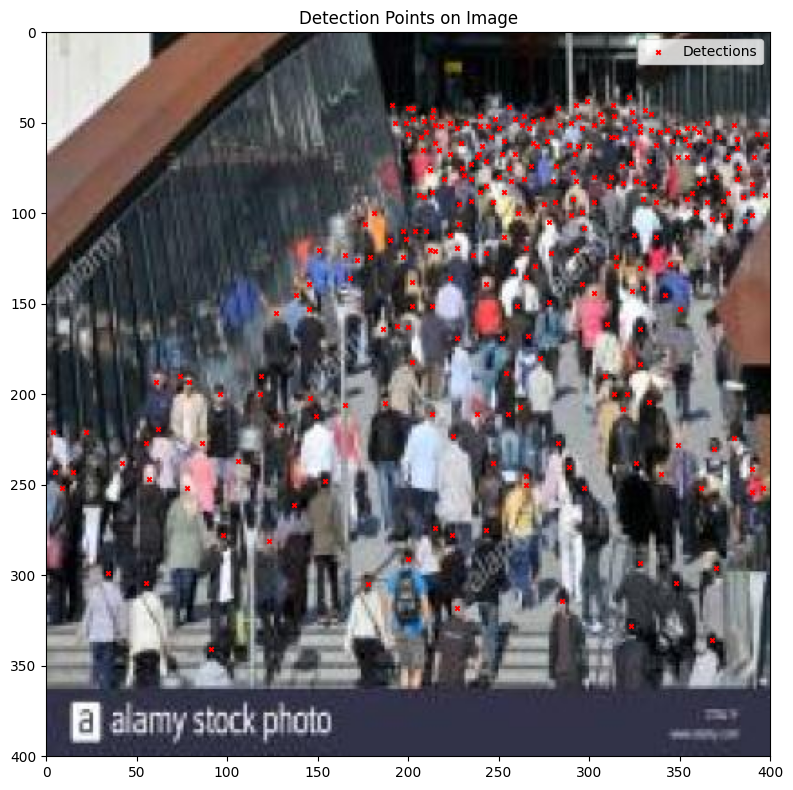

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


# Get scatter point coordinates from the matrix
y_coords, x_coords = np.where(matrix == 1)

# Load background image
img = mpimg.imread('img_1006_jpg.rf.da523bb4696e89f598f0f1514f19106e.jpg')

fig, ax = plt.subplots(figsize=(8, 8))

# Show image as background
ax.imshow(img, extent=[0, 400, 400, 0])  # extent matches 400x400, origin top-left

# Scatter plot the points
ax.scatter(x_coords, y_coords, c='red', s=10, marker='x', label='Detections')

ax.set_xlim(0, 400)
ax.set_ylim(400, 0)  # Flip y-axis so origin is top-left (matches image coords)
ax.legend()
ax.set_title('Detection Points on Image')
plt.tight_layout()
plt.show()

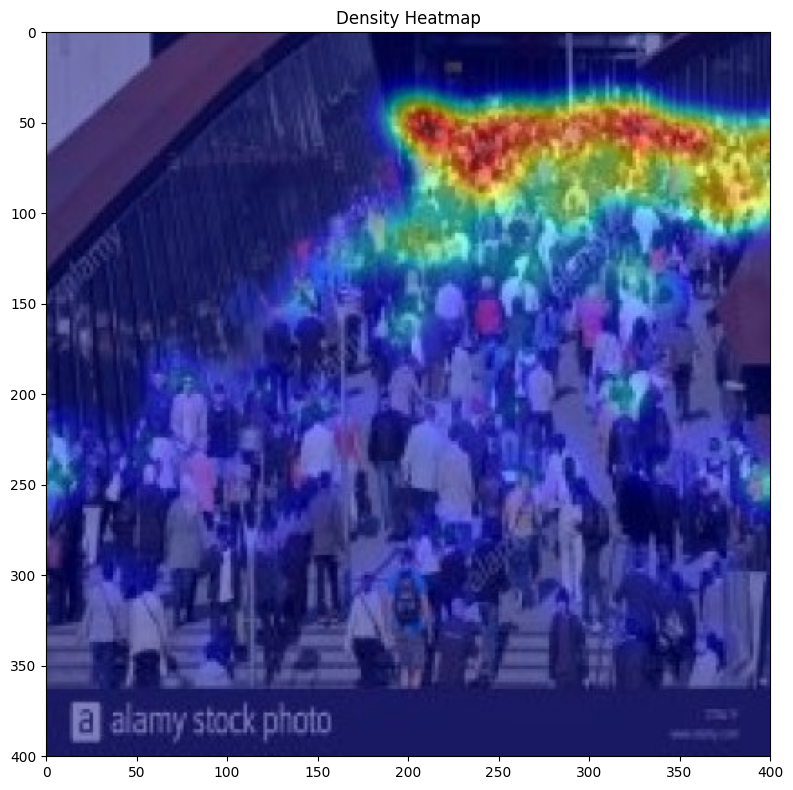

In [ ]:
from scipy.ndimage import gaussian_filter

# Get scatter point coordinates from the matrix
y_coords, x_coords = np.where(matrix == 1)

# Load background image
img = mpimg.imread('img_1006_jpg.rf.da523bb4696e89f598f0f1514f19106e.jpg')

# Create heatmap by smoothing the matrix with a Gaussian filter
heatmap = gaussian_filter(matrix.astype(float), sigma=3)

fig, ax = plt.subplots(figsize=(8, 8))

# Show image as background
ax.imshow(img, extent=[0, 400, 400, 0])

# Overlay heatmap
ax.imshow(heatmap, extent=[0, 400, 400, 0], cmap='hot', alpha=0.5, origin='upper')

ax.set_xlim(0, 400)
ax.set_ylim(400, 0)
ax.set_title('Density Heatmap')
plt.tight_layout()
plt.show()
